# 02. Econometric Baseline: GARCH & HAR-RV Walk-Forward
**Models:** GARCH(1,1)  ·  EGARCH(1,1)  ·  GJR-GARCH(1,1)  ·  HAR-RV  
**Assets:** 18 (3 indices + 15 stocks)  |  **Test period:** Jan 2018 – Dec 2025  
**Horizons:** 1-day, 5-day, 20-day ahead  
**Output:** `data/processed/forecasts_{model}.csv`

In [ ]:
import sys, os, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from joblib import Parallel, delayed

from src.data import load_and_clean, ASSETS, TEST_START, TRAIN_END, fetch_vix_daily
from src.models import GARCHModel, HARRVModel, HARXModel
from src.evaluation import evaluate_forecasts, regime_evaluation, forecast_vs_iv_accuracy

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

PROCESSED = '../data/processed'
FIGDIR    = '../results/figures'
os.makedirs(FIGDIR, exist_ok=True)

# Month-end refit dates: Dec 2017 is the last training point, Dec 2025 is the last test point
REFIT_DATES = pd.date_range('2017-12-31', '2025-12-31', freq='ME')
print(f"Refit dates: {len(REFIT_DATES)}  ({REFIT_DATES[0].date()} – {REFIT_DATES[-1].date()})")
print(f"Assets: {ASSETS}")

# Daily VIX (SPY's ^VIX used as a market-wide proxy for every ticker) — used by HAR-X only.
vix_daily = fetch_vix_daily()

## Walk-forward loop

In [ ]:
def _get_targets(rv: pd.Series, refit_date: pd.Timestamp) -> tuple[float, float, float]:
    """Return rv_21d values at +1, +5, +20 trading days after refit_date."""
    future = rv.loc[rv.index > refit_date]
    h1  = float(future.iloc[0])  if len(future) >= 1  else np.nan
    h5  = float(future.iloc[4])  if len(future) >= 5  else np.nan
    h20 = float(future.iloc[19]) if len(future) >= 20 else np.nan
    return h1, h5, h20


def walk_forward_one(ticker: str, model_name: str, vix_series: pd.Series = None) -> pd.DataFrame:
    """
    Walk-forward fit + forecast for one ticker and one model.
    Returns a DataFrame with columns:
        date, ticker, model, h1, h5, h20, rv_h1, rv_h5, rv_h20
    """
    df  = load_and_clean(ticker, raw_dir='../data/raw')
    ret = df['return'].dropna()
    rv  = df['rv_21d'].dropna()

    records = []
    for t in REFIT_DATES[:-1]:   # last date has no future targets
        # --- fit ----------------------------------------------------------
        if model_name == 'Persistence':
            # Naive floor: forecast = rv_21d observed AT t, no fitting. Reused
            # for h1/h5/h20, same convention as HAR-RV's single-forecast reuse.
            rv_train = rv.loc[:t]
            if len(rv_train) < 1:
                continue
            h1 = h5 = h20 = float(rv_train.iloc[-1])
        elif model_name == 'HAR-RV':
            m = HARRVModel()
            m.fit(rv.loc[:t])
            fc_val = m.forecast()
            h1 = h5 = h20 = fc_val          # HAR-RV gives one forecast
        elif model_name == 'HAR-X':
            m = HARXModel()
            m.fit(rv.loc[:t], vix_series.loc[:t])
            fc_val = m.forecast()
            h1 = h5 = h20 = fc_val          # HAR-X gives one forecast, like HAR-RV
        else:
            vol, o = {
                'GARCH(1,1)':   ('Garch', 0),
                'EGARCH(1,1)':  ('EGARCH', 0),
                'GJR-GARCH(1,1)': ('Garch', 1),
            }[model_name]
            m = GARCHModel(vol=vol, o=o, p=1, q=1)
            m.fit(ret.loc[:t])
            fc = m.forecast(horizon=20)
            h1, h5, h20 = float(fc[0]), float(fc[4]), float(fc[19])

        # --- targets ------------------------------------------------------
        rv_h1, rv_h5, rv_h20 = _get_targets(rv, t)

        records.append({
            'date': t, 'ticker': ticker, 'model': model_name,
            'h1': h1, 'h5': h5, 'h20': h20,
            'rv_h1': rv_h1, 'rv_h5': rv_h5, 'rv_h20': rv_h20,
        })

    return pd.DataFrame(records)


print("walk_forward_one() defined — ready to run")

## Run all 4 models × 18 assets
Parallelised over assets (`n_jobs=-1`). Expect ~15–25 min total.

In [ ]:
MODELS = ['GARCH(1,1)', 'EGARCH(1,1)', 'GJR-GARCH(1,1)', 'HAR-RV', 'HAR-X', 'Persistence']
MODEL_KEYS = {
    'GARCH(1,1)':     'garch11',
    'EGARCH(1,1)':    'egarch',
    'GJR-GARCH(1,1)': 'gjr',
    'HAR-RV':         'harv',
    'HAR-X':          'harx',
    'Persistence':    'persistence',
}

all_forecasts: dict[str, pd.DataFrame] = {}

for model_name in MODELS:
    print(f"\n>>> Running {model_name} ...", flush=True)
    results = Parallel(n_jobs=-1, verbose=0)(
        delayed(walk_forward_one)(ticker, model_name, vix_daily)
        for ticker in ASSETS
    )
    df_model = pd.concat(results, ignore_index=True)

    # Save to CSV
    key  = MODEL_KEYS[model_name]
    path = os.path.join(PROCESSED, f'forecasts_{key}.csv')
    df_model.to_csv(path, index=False)
    print(f"    Saved {len(df_model):,} rows → {path}")

    all_forecasts[model_name] = df_model

print("\n✓ All models complete")

In [4]:
# Sanity checks
df_g = all_forecasts['GARCH(1,1)']
spy_g = df_g[df_g['ticker'] == 'SPY']

print("=== GARCH(1,1) SPY spot-check ===")
print(f"Rows: {len(spy_g)}  (expected 95 — 96 refit dates minus last)")
print(f"h1 range: {spy_g['h1'].min():.1f}% – {spy_g['h1'].max():.1f}%  "
      f"(expect ~7–80% annualised)")
print(f"NaN in h1: {spy_g['h1'].isna().sum()}")
print()
print(spy_g[['date','h1','h5','h20','rv_h1']].tail(5).round(2).to_string(index=False))

=== GARCH(1,1) SPY spot-check ===
Rows: 96  (expected 95 — 96 refit dates minus last)
h1 range: 7.9% – 62.3%  (expect ~7–80% annualised)
NaN in h1: 0

      date    h1    h5   h20  rv_h1
2025-07-31  8.60 10.03 13.29   8.94
2025-08-31 10.98 11.92 14.26  10.62
2025-09-30  9.02 10.35 13.42   6.38
2025-10-31 12.61 13.27 14.97  14.41
2025-11-30 14.88 15.20 16.05  14.71


## Statistical evaluation
`evaluate_forecasts()` is called separately for each horizon.  
We report the **cross-asset mean** RMSE/MAE/QLIKE/DirAcc for a single summary table.

In [5]:
def eval_model_horizon(forecasts_df: pd.DataFrame, horizon: str = 'h1') -> pd.Series:
    """Cross-asset mean of each metric for one model at one horizon."""
    metric_rows = []
    for ticker in ASSETS:
        sub = forecasts_df[forecasts_df['ticker'] == ticker].dropna(
            subset=[horizon, f'rv_{horizon}']
        )
        if len(sub) < 5:
            continue
        fc_dict = {sub['model'].iloc[0]: sub[horizon].values}
        rv_true = sub[f'rv_{horizon}']
        row = evaluate_forecasts(rv_true, fc_dict)
        metric_rows.append(row)
    combined = pd.concat(metric_rows)
    return combined.mean()   # cross-asset mean


# Build summary table for 1-day horizon
rows = []
for model_name, df_model in all_forecasts.items():
    s = eval_model_horizon(df_model, 'h1')
    s.name = model_name
    rows.append(s)

summary_h1 = pd.DataFrame(rows).round(3)
print("=== Cross-asset mean metrics — 1-day ahead horizon ===")
display(summary_h1.sort_values('RMSE'))

=== Cross-asset mean metrics — 1-day ahead horizon ===


,RMSE,MAE,QLIKE,DirAcc
"GARCH(1,1)",6.255,4.072,2.224,0.797
"GJR-GARCH(1,1)",6.949,4.640,2.219,0.763
"EGARCH(1,1)",7.364,4.348,2.226,0.790
HAR-RV,17.964,16.065,3.042,0.889


In [6]:
print("=== Cross-asset mean RMSE by model and horizon ===")
rmse_rows = []
for model_name, df_model in all_forecasts.items():
    row = {'Model': model_name}
    for h_label in ['h1', 'h5', 'h20']:
        s = eval_model_horizon(df_model, h_label)
        row[f'RMSE_{h_label}'] = round(s['RMSE'], 3)
    rmse_rows.append(row)

rmse_df = pd.DataFrame(rmse_rows).set_index('Model')
display(rmse_df)
rmse_df.to_csv('../results/forecast_accuracy_econometric.csv')
print("Saved → ../results/forecast_accuracy_econometric.csv")

=== Cross-asset mean RMSE by model and horizon ===


,RMSE_h1,RMSE_h5,RMSE_h20
Model,,,
"GARCH(1,1)",6.255,6.586,12.185
"EGARCH(1,1)",7.364,7.875,12.360
"GJR-GARCH(1,1)",6.949,6.946,12.036
HAR-RV,17.964,19.323,25.976


Saved → ../results/forecast_accuracy_econometric.csv


## Regime-stratified evaluation
Does GARCH performance degrade in high-volatility regimes?  
Compare RMSE for SPY across low / medium / high regime periods.

In [7]:
spy_df = load_and_clean('SPY', raw_dir='../data/raw')

print("=== SPY regime evaluation — 1-day ahead horizon ===")
for model_name, df_model in all_forecasts.items():
    sub = df_model[(df_model['ticker'] == 'SPY')].dropna(subset=['h1','rv_h1']).reset_index(drop=True)
    if len(sub) == 0:
        continue

    # Build arrays aligned by integer position (avoids date-vs-int index mismatch)
    regime_vals = spy_df['regime'].reindex(sub['date'].values).values
    regimes = pd.Series(regime_vals, name='regime')
    rv_true  = pd.Series(sub['rv_h1'].values, name='rv_h1')
    fc_dict  = {model_name: sub['h1'].values}

    regime_res = regime_evaluation(rv_true, fc_dict, regimes)
    rmses = {r: regime_res[r].loc[model_name, 'RMSE'] for r in regime_res}
    print(f"  {model_name:<20}  low:{rmses.get('low', float('nan')):.2f}  "
          f"med:{rmses.get('medium', float('nan')):.2f}  high:{rmses.get('high', float('nan')):.2f}")

=== SPY regime evaluation — 1-day ahead horizon ===
  GARCH(1,1)            low:2.58  med:2.88  high:13.81
  EGARCH(1,1)           low:2.73  med:2.40  high:18.21
  GJR-GARCH(1,1)        low:3.58  med:4.08  high:16.26
  HAR-RV                low:2.90  med:5.55  high:11.21


## Forecast accuracy vs. VIX (implied vol benchmark)
Do econometric models outperform the options market as a predictor of future SPY vol?

In [8]:
iv = pd.read_csv('../data/processed/iv_monthly.csv', index_col=0, parse_dates=True)

# Build forward rv_21d on month-end dates (same construction as VRP notebook)
spy_rv = load_and_clean('SPY', raw_dir='../data/raw')['rv_21d'].dropna()
rv_fwd = {
    date: spy_rv.loc[spy_rv.index[spy_rv.index > date][20]]
    for date in iv.index
    if len(spy_rv.index[spy_rv.index > date]) >= 21
}
rv_fwd_series = pd.Series(rv_fwd, name='rv_fwd_21d').dropna()

# Build forecast dict: one entry per model (h1 forecast at month-end dates)
fc_dict_spy = {}
for model_name, df_model in all_forecasts.items():
    sub = df_model[(df_model['ticker'] == 'SPY')].set_index('date')['h1'].dropna()
    fc_dict_spy[model_name] = sub.reindex(rv_fwd_series.index)

tbl_iv = forecast_vs_iv_accuracy(
    fc_dict_spy,
    iv['SPY'].reindex(rv_fwd_series.index),
    rv_fwd_series,
)
print("=== SPY: Econometric models vs. VIX as forecast of future RV ===")
print("(negative vs_IV_RMSE_diff = model beats the options market)")
display(tbl_iv.round(3))

=== SPY: Econometric models vs. VIX as forecast of future RV ===
(negative vs_IV_RMSE_diff = model beats the options market)


,RMSE,MAE,QLIKE,DirAcc,vs_IV_RMSE_diff
model,,,,,
"GJR-GARCH(1,1)",8.627,5.794,1.760,0.511,-0.959
"GARCH(1,1)",9.073,5.690,1.791,0.468,-0.512
"EGARCH(1,1)",9.096,5.480,1.810,0.426,-0.490
Implied Vol (VIX),9.586,6.776,2.267,0.532,0.000
HAR-RV,14.428,8.928,2.168,0.383,4.843


## Figure 5 — SPY 1-day forecasts vs. realized vol (2018–2025)

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Figure 5: SPY Econometric Model Forecasts vs. Realized Volatility (2018–2025)',
             fontsize=13, fontweight='bold')

COLORS = {'GARCH(1,1)':'#1f77b4', 'EGARCH(1,1)':'#ff7f0e',
          'GJR-GARCH(1,1)':'#2ca02c', 'HAR-RV':'#9467bd',
          'HAR-X':'#8c564b', 'Persistence':'#7f7f7f'}

# Actual RV (daily for smooth line)
spy_rv_daily = load_and_clean('SPY', raw_dir='../data/raw')['rv_21d'].dropna().loc['2018-01-01':]
ax.plot(spy_rv_daily.index, spy_rv_daily, color='black', lw=1.2, alpha=0.6,
        label='Actual rv_21d', zorder=5)

# Model forecasts at month-end dates
for model_name, df_model in all_forecasts.items():
    sub = df_model[df_model['ticker'] == 'SPY'].dropna(subset=['h1'])
    ax.plot(sub['date'], sub['h1'], 'o--', color=COLORS[model_name],
            ms=4, lw=1.2, alpha=0.85, label=model_name)

ax.set_ylabel('Annualised Volatility (%)')
ax.set_xlabel('Year')
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
path = os.path.join(FIGDIR, 'fig5_garch_forecasts_spy.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved → {path}")

## Residual diagnostics

Fit each econometric model once on the **full** SPY sample (not walk-forward — this is a
one-shot specification check, not a forecast) and test whether the standardized residuals
behave like white noise. If a GARCH-family model has adequately captured the volatility
clustering, its standardized residuals (`resid / conditional_volatility`) should show no
remaining autocorrelation — checked here with a Ljung-Box test (lag 20), an ACF plot, and a
QQ plot against the normal distribution. HAR-RV has no conditional-volatility term, so its
raw OLS regression residuals are used instead of a standardized version.

In [10]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot

spy_ret_full = spy_df['return'].dropna()

diag_models = {
    'GARCH(1,1)':     GARCHModel(vol='Garch', o=0, p=1, q=1),
    'EGARCH(1,1)':    GARCHModel(vol='EGARCH', o=0, p=1, q=1),
    'GJR-GARCH(1,1)': GARCHModel(vol='Garch', o=1, p=1, q=1),
}

std_resids: dict[str, pd.Series] = {}
for name, m in diag_models.items():
    m.fit(spy_ret_full)
    std_resids[name] = pd.Series(m.result.std_resid)

# HAR-RV has no conditional-volatility scaling — use raw OLS residuals instead.
harv_full = HARRVModel()
harv_full.fit(spy_df['rv_21d'].dropna())
std_resids['HAR-RV'] = pd.Series(harv_full.result.resid)

print("=== Ljung-Box test on residuals (lag=20) ===")
print("(p < 0.05  =>  residuals still show significant autocorrelation  =>  model misspecified)")
lb_rows = []
for name, resid in std_resids.items():
    lb = acorr_ljungbox(resid.dropna(), lags=[20], return_df=True)
    lb_rows.append({'Model': name, 'LB stat': lb['lb_stat'].iloc[0], 'p-value': lb['lb_pvalue'].iloc[0]})
lb_df = pd.DataFrame(lb_rows).set_index('Model').round(4)
display(lb_df)

=== Ljung-Box test on residuals (lag=20) ===
(p < 0.05  =>  residuals still show significant autocorrelation  =>  model misspecified)


,LB stat,p-value
Model,,
"GARCH(1,1)",26.5778,0.1476
"EGARCH(1,1)",27.1646,0.1307
"GJR-GARCH(1,1)",24.8132,0.2087
HAR-RV,42.8888,0.0021


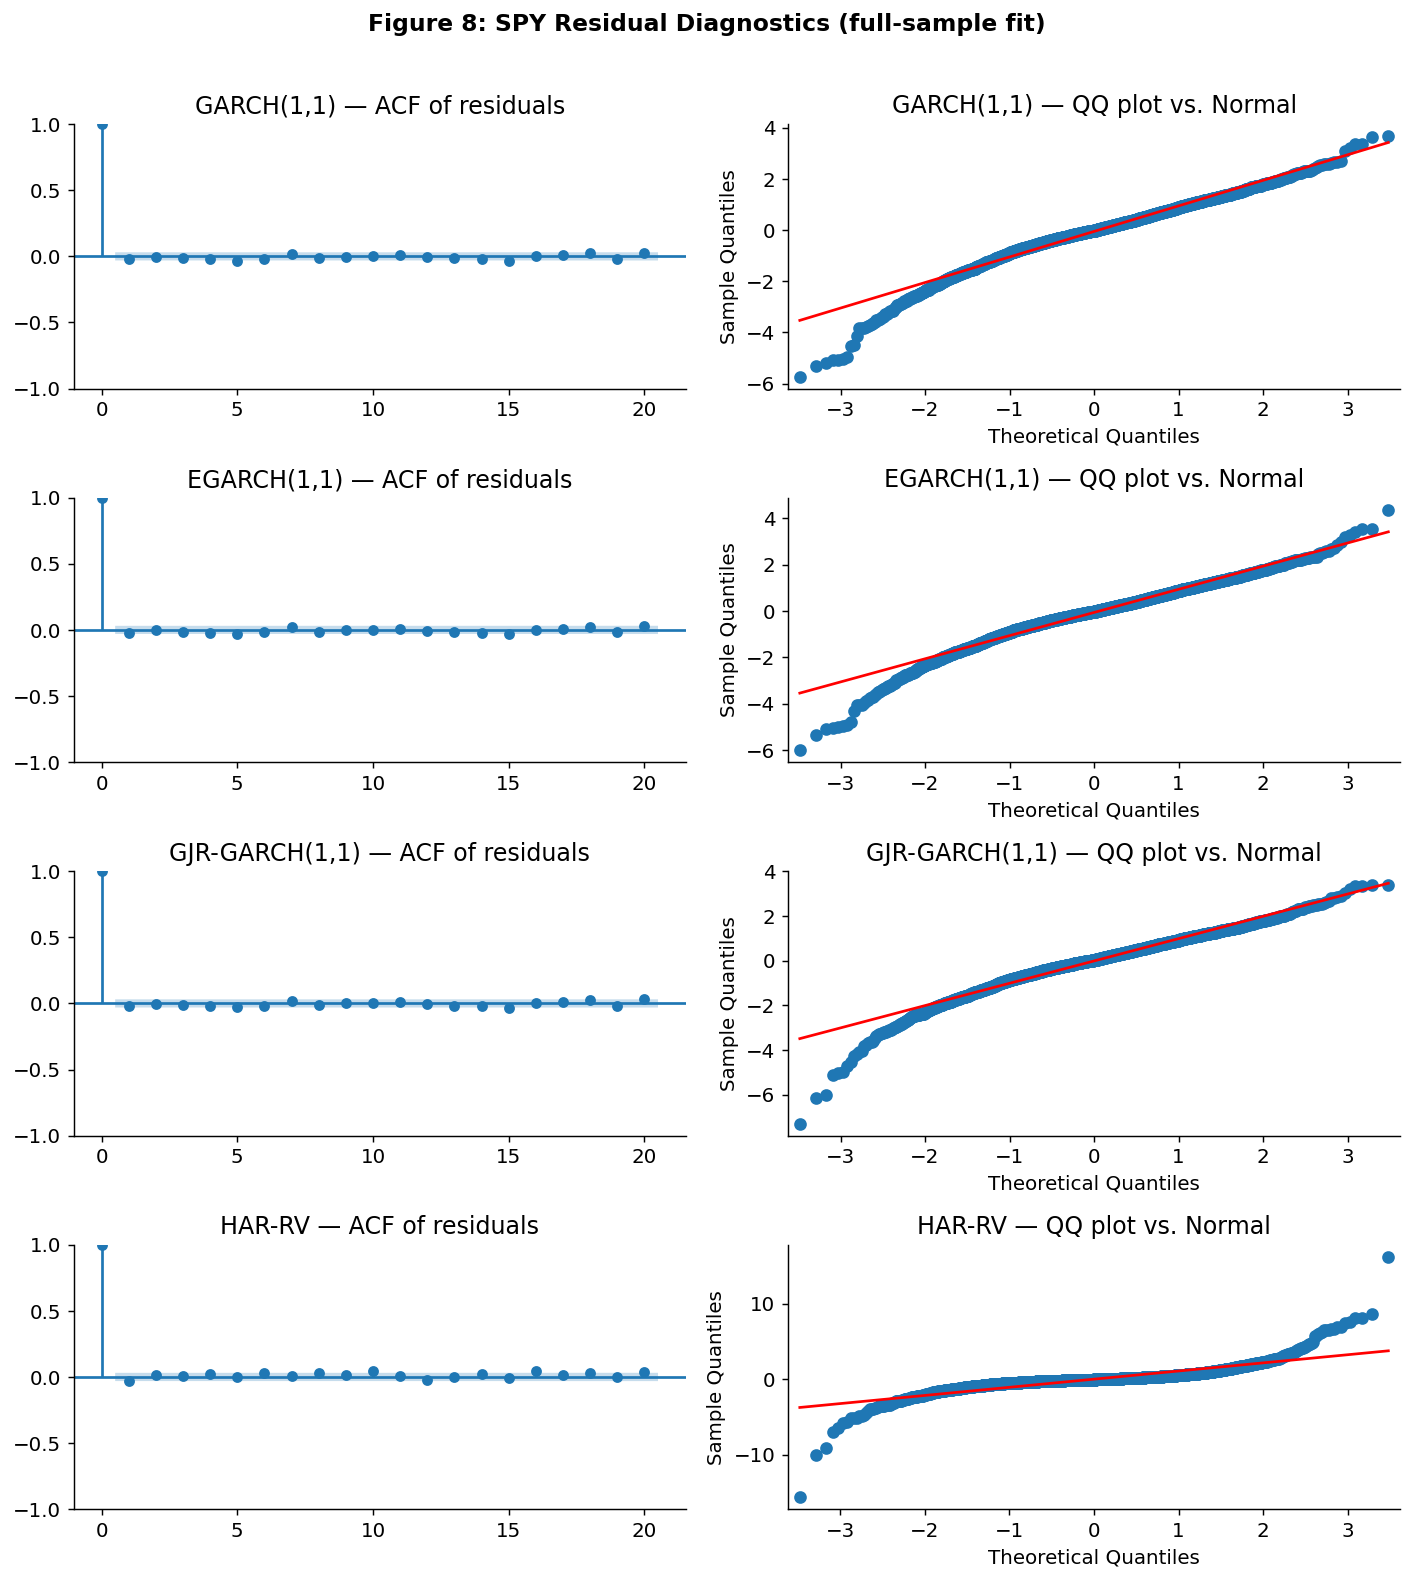

Saved → ../results/figures/fig8_residual_diagnostics.png


In [11]:
fig, axes = plt.subplots(len(std_resids), 2, figsize=(11, 3 * len(std_resids)))
fig.suptitle('Figure 8: SPY Residual Diagnostics (full-sample fit)',
             fontsize=13, fontweight='bold', y=1.01)

for i, (name, resid) in enumerate(std_resids.items()):
    r = resid.dropna()
    plot_acf(r, lags=20, ax=axes[i, 0], title=f'{name} — ACF of residuals')
    qqplot(r, line='s', ax=axes[i, 1])
    axes[i, 1].set_title(f'{name} — QQ plot vs. Normal')

plt.tight_layout()
path = os.path.join(FIGDIR, 'fig8_residual_diagnostics.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved → {path}")